# Retail Site Selection - Gravity Model Analysis

## 🏪 Business Context
Optimal location selection for retail facilities using multi-criteria scoring and gravity models.

**Key Objectives**:
- Apply Huff gravity model for market area delineation
- Implement Reilly's law of retail gravitation
- Multi-criteria site scoring (population, accessibility, competition)
- Generate Thiessen polygons for territory analysis
- Analyze competitive overlap and market potential

**Study Area**: Accra, Ghana

**Applications**: Retail expansion, real estate investment, market analysis

In [1]:
# Import Libraries
import ee
import geemap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.spatial import Voronoi, voronoi_plot_2d
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

plt.style.use('seaborn-v0_8-whitegrid')
print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


In [2]:
# Define Study Area - Accra, Ghana
accra_center = ee.Geometry.Point([-0.1870, 5.6037])
accra_metro = accra_center.buffer(20000)

print(f'Study Area: {accra_metro.area().divide(1e6).getInfo():.2f} km²')

Study Area: 1241.62 km²


In [3]:
# Load Data
# Population
worldpop = ee.ImageCollection('WorldPop/GP/100m/pop') \
    .filter(ee.Filter.eq('country', 'GHA')) \
    .filter(ee.Filter.eq('year', 2020)) \
    .first().clip(accra_metro)

# Nighttime lights (income proxy)
viirs = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG') \
    .filterDate('2020-01-01', '2020-12-31') \
    .select('avg_rad') \
    .median().clip(accra_metro)

print('✓ Datasets loaded')

✓ Datasets loaded


In [4]:
# Define Existing Competitors (synthetic)
competitors = pd.DataFrame({
    'name': ['Store_A', 'Store_B', 'Store_C', 'Store_D'],
    'lon': [-0.20, -0.17, -0.22, -0.15],
    'lat': [5.61, 5.60, 5.58, 5.62],
    'size': [5000, 3000, 4000, 3500]  # sq meters
})

# Candidate Sites (to evaluate)
candidates = pd.DataFrame({
    'site_id': ['Site_1', 'Site_2', 'Site_3', 'Site_4', 'Site_5'],
    'lon': [-0.19, -0.16, -0.21, -0.18, -0.14],
    'lat': [5.59, 5.61, 5.60, 5.63, 5.58]
})

print(f'Competitors: {len(competitors)}')
print(f'Candidate sites: {len(candidates)}')

Competitors: 4
Candidate sites: 5


In [5]:
# Multi-Criteria Scoring
# Extract metrics for each candidate

def evaluate_site(lon, lat, buffer_m=1000):
    point = ee.Geometry.Point([lon, lat]).buffer(buffer_m)
    
    # Population within 1km
    pop = worldpop.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=point,
        scale=100,
        maxPixels=1e9
    ).get('population').getInfo()
    
    # Income proxy (nighttime lights)
    income = viirs.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point,
        scale=500,
        maxPixels=1e9
    ).get('avg_rad').getInfo()
    
    # Distance to nearest competitor
    comp_dists = np.sqrt(
        (competitors['lon'] - lon)**2 + (competitors['lat'] - lat)**2
    ) * 111  # Convert to km
    min_comp_dist = comp_dists.min()
    
    return {
        'population_1km': pop if pop else 0,
        'income_proxy': income if income else 0,
        'min_competitor_dist_km': min_comp_dist
    }

print('Evaluating candidate sites...')
candidate_scores = []
for _, row in candidates.iterrows():
    scores = evaluate_site(row['lon'], row['lat'])
    candidate_scores.append(scores)

scores_df = pd.concat([candidates, pd.DataFrame(candidate_scores)], axis=1)
print('\nCandidate Site Scores:')
display(scores_df)

Evaluating candidate sites...

Candidate Site Scores:


,site_id,lon,lat,population_1km,income_proxy,min_competitor_dist_km
0,Site_1,-0.19,5.59,44984.289700,37.361679,2.482035
1,Site_2,-0.16,5.61,22153.725144,16.891276,1.569777
2,Site_3,-0.21,5.60,47147.206811,35.455739,1.569777
3,Site_4,-0.18,5.63,39282.448439,26.341467,3.139554
4,Site_5,-0.14,5.58,29188.675111,28.972764,4.002162


In [6]:
# Weighted Scoring
# Normalize and apply weights

def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

scores_df['pop_score'] = normalize(scores_df['population_1km'])
scores_df['income_score'] = normalize(scores_df['income_proxy'])
scores_df['competition_score'] = normalize(scores_df['min_competitor_dist_km'])  # Higher is better

# Weights
weights = {'population': 0.4, 'income': 0.35, 'competition': 0.25}

scores_df['total_score'] = (
    scores_df['pop_score'] * weights['population'] +
    scores_df['income_score'] * weights['income'] +
    scores_df['competition_score'] * weights['competition']
)

scores_df = scores_df.sort_values('total_score', ascending=False)
print('\nRanked Candidates:')
display(scores_df[['site_id', 'total_score', 'pop_score', 'income_score', 'competition_score']])


Ranked Candidates:


,site_id,total_score,pop_score,income_score,competition_score
0,Site_1,0.809146,0.913461,1.000000,3.750469e-01
2,Site_3,0.717413,1.000000,0.906893,2.765990e-14
3,Site_4,0.597050,0.685328,0.461651,6.453654e-01
4,Site_5,0.569156,0.281471,0.590193,1.000000e+00
1,Site_2,0.000000,0.000000,0.000000,0.000000e+00


In [7]:
# Huff Gravity Model
# Probability of patronage based on attraction / distance

def huff_model(customer_coords, store_coords, store_sizes, distance_decay=2.0):
    """Calculate probability of visiting each store from customer location."""
    # Distance from customer to each store
    distances = cdist(customer_coords, store_coords) * 111  # to km
    
    # Attraction = Size / Distance^decay
    attractions = store_sizes / (distances ** distance_decay)
    
    # Probability = Attraction_i / Sum(Attractions)
    probabilities = attractions / attractions.sum(axis=1, keepdims=True)
    
    return probabilities

# Create grid of customer locations
grid_res = 0.01  # degrees
lon_grid = np.arange(-0.25, -0.10, grid_res)
lat_grid = np.arange(5.55, 5.65, grid_res)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
customer_coords = np.column_stack([lon_mesh.ravel(), lat_mesh.ravel()])

# Apply Huff model
store_coords = competitors[['lon', 'lat']].values
store_sizes = competitors['size'].values

probs = huff_model(customer_coords, store_coords, store_sizes)

# Market share = sum of probabilities weighted by local population
market_share = probs.sum(axis=0) / probs.sum()
print('\nMarket Share (Huff Model):')
for i, name in enumerate(competitors['name']):
    print(f'{name}: {market_share[i]*100:.1f}%')


Market Share (Huff Model):
Store_A: 29.7%
Store_B: 20.3%
Store_C: 24.8%
Store_D: 25.2%


In [8]:
# Thiessen Polygons (Voronoi)
# Market territories based on proximity

all_stores = pd.concat([competitors[['lon', 'lat']], candidates[['lon', 'lat']]])
vor = Voronoi(all_stores.values)

print(f'✓ Thiessen polygons created for {len(all_stores)} locations')

✓ Thiessen polygons created for 9 locations


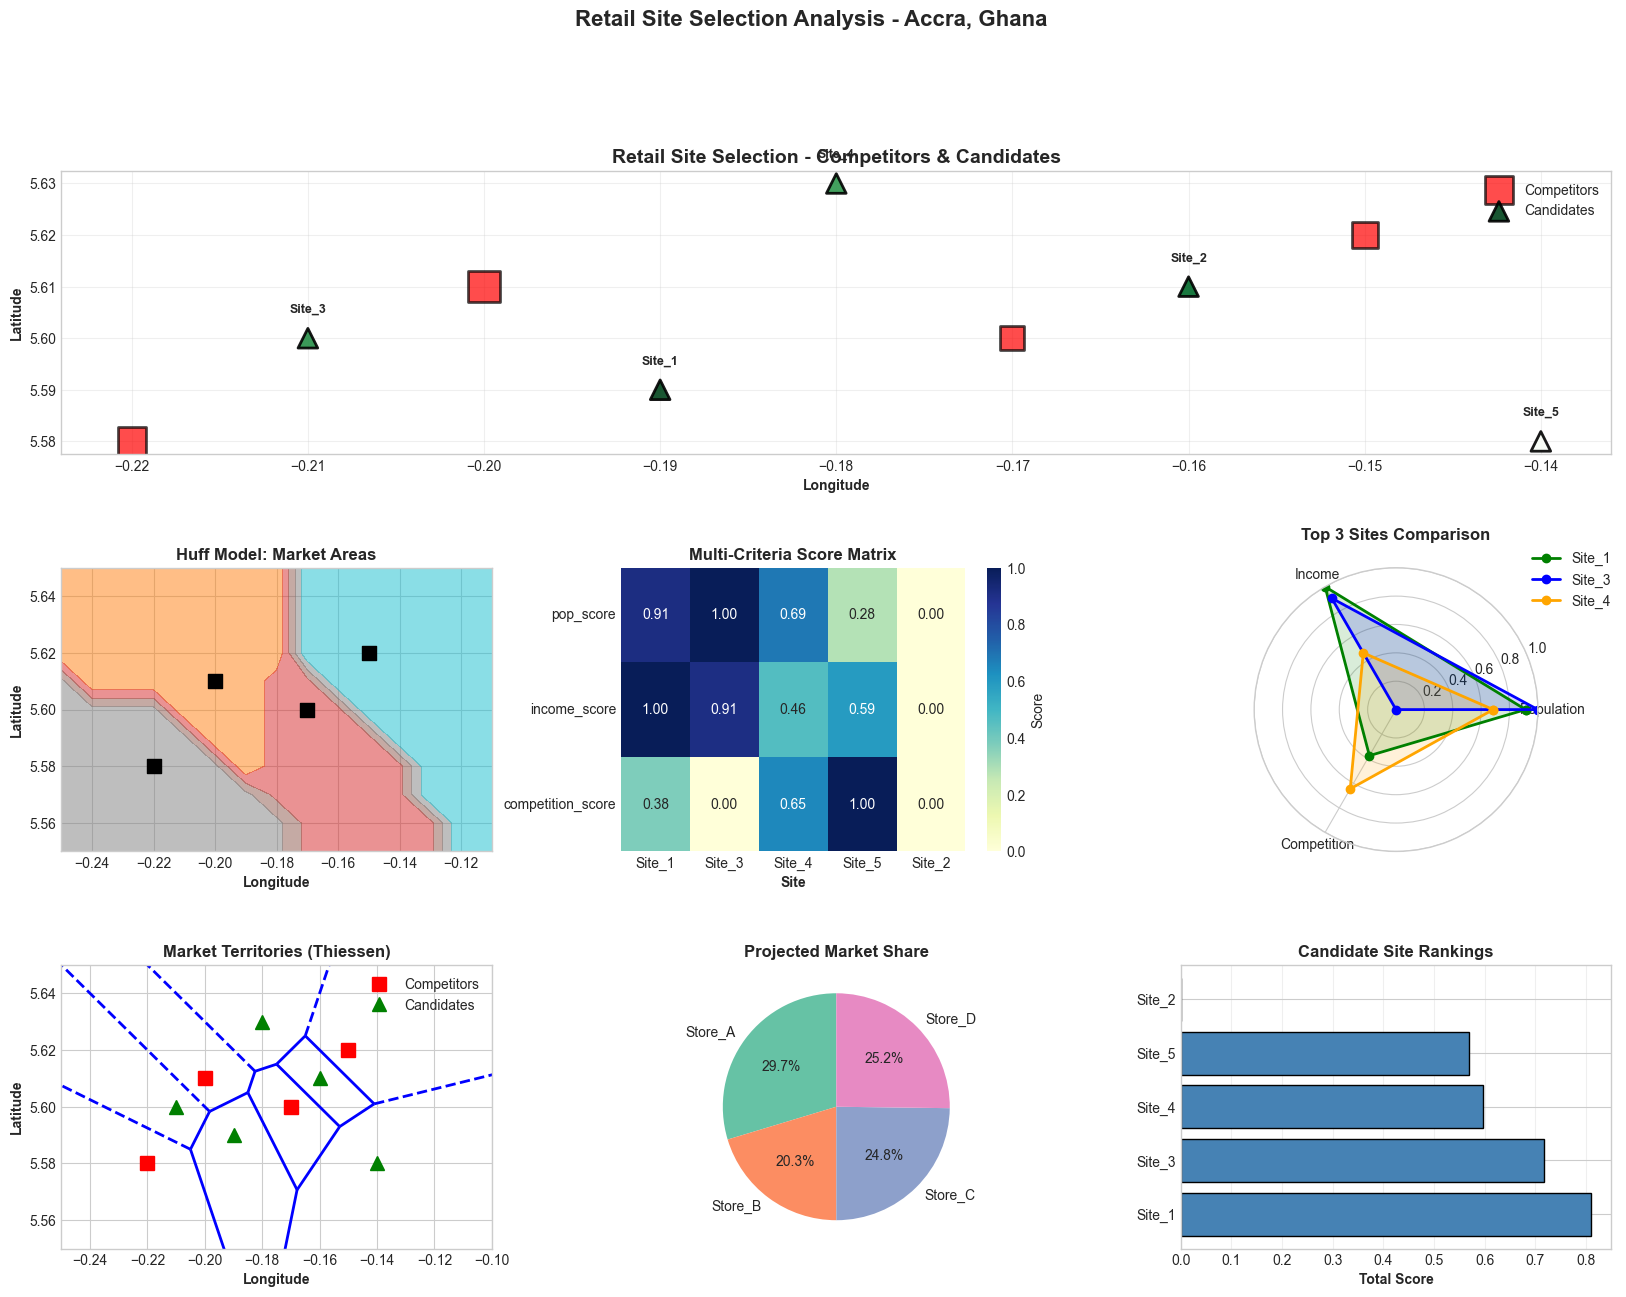

In [9]:
# Visualizations
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Site Locations Map
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(competitors['lon'], competitors['lat'], s=competitors['size']/10, 
           c='red', marker='s', label='Competitors', alpha=0.7, edgecolors='black', linewidth=2)
ax1.scatter(candidates['lon'], candidates['lat'], s=200, c=scores_df['total_score'], 
           cmap='Greens', marker='^', label='Candidates', alpha=0.9, edgecolors='black', linewidth=2)
for _, row in scores_df.iterrows():
    ax1.text(row['lon'], row['lat']+0.005, row['site_id'], ha='center', fontweight='bold', fontsize=9)
ax1.set_xlabel('Longitude', fontweight='bold')
ax1.set_ylabel('Latitude', fontweight='bold')
ax1.set_title('Retail Site Selection - Competitors & Candidates', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Huff Gravity Probability Surface
ax2 = fig.add_subplot(gs[1, 0])
dominant_store = probs.argmax(axis=1).reshape(lon_mesh.shape)
im = ax2.contourf(lon_mesh, lat_mesh, dominant_store, levels=4, cmap='tab10', alpha=0.5)
ax2.scatter(competitors['lon'], competitors['lat'], s=100, c='black', marker='s')
ax2.set_xlabel('Longitude', fontweight='bold')
ax2.set_ylabel('Latitude', fontweight='bold')
ax2.set_title('Huff Model: Market Areas', fontweight='bold')

# 3. Site Score Matrix Heatmap
ax3 = fig.add_subplot(gs[1, 1])
score_matrix = scores_df.set_index('site_id')[['pop_score', 'income_score', 'competition_score']]
sns.heatmap(score_matrix.T, annot=True, cmap='YlGnBu', ax=ax3, fmt='.2f', cbar_kws={'label': 'Score'})
ax3.set_xlabel('Site', fontweight='bold')
ax3.set_title('Multi-Criteria Score Matrix', fontweight='bold')

# 4. Spider Chart - Top 3 Sites
ax4 = fig.add_subplot(gs[1, 2], projection='polar')
categories = ['Population', 'Income', 'Competition']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

top_3 = scores_df.head(3)
colors = ['green', 'blue', 'orange']
for idx, (_, row) in enumerate(top_3.iterrows()):
    values = [row['pop_score'], row['income_score'], row['competition_score']]
    values += values[:1]
    ax4.plot(angles, values, 'o-', linewidth=2, label=row['site_id'], color=colors[idx])
    ax4.fill(angles, values, alpha=0.15, color=colors[idx])

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories)
ax4.set_ylim(0, 1)
ax4.set_title('Top 3 Sites Comparison', fontweight='bold', pad=20)
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax4.grid(True)

# 5. Thiessen Polygons
ax5 = fig.add_subplot(gs[2, 0])
voronoi_plot_2d(vor, ax=ax5, show_vertices=False, line_colors='blue', line_width=2, point_size=0)
ax5.plot(competitors['lon'], competitors['lat'], 'rs', markersize=10, label='Competitors')
ax5.plot(candidates['lon'], candidates['lat'], 'g^', markersize=10, label='Candidates')
ax5.set_xlim(-0.25, -0.10)
ax5.set_ylim(5.55, 5.65)
ax5.set_xlabel('Longitude', fontweight='bold')
ax5.set_ylabel('Latitude', fontweight='bold')
ax5.set_title('Market Territories (Thiessen)', fontweight='bold')
ax5.legend()

# 6. Market Share Pie
ax6 = fig.add_subplot(gs[2, 1])
ax6.pie(market_share, labels=competitors['name'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
ax6.set_title('Projected Market Share', fontweight='bold')

# 7. Site Ranking Bar Chart
ax7 = fig.add_subplot(gs[2, 2])
ax7.barh(scores_df['site_id'], scores_df['total_score'], color='steelblue', edgecolor='black')
ax7.set_xlabel('Total Score', fontweight='bold')
ax7.set_title('Candidate Site Rankings', fontweight='bold')
ax7.grid(axis='x', alpha=0.3)

plt.suptitle('Retail Site Selection Analysis - Accra, Ghana', fontsize=16, fontweight='bold', y=0.995)
plt.show()


=== Competitor Distance Analysis ===
  Candidate Nearest_Competitor  Distance_km              Risk_Level
0    Site_1            Store_B     2.482035                  Medium
1    Site_2            Store_D     1.569777  High (Cannibalization)
2    Site_3            Store_A     1.569777  High (Cannibalization)
3    Site_4            Store_A     3.139554                  Medium
4    Site_5            Store_B     4.002162                  Medium


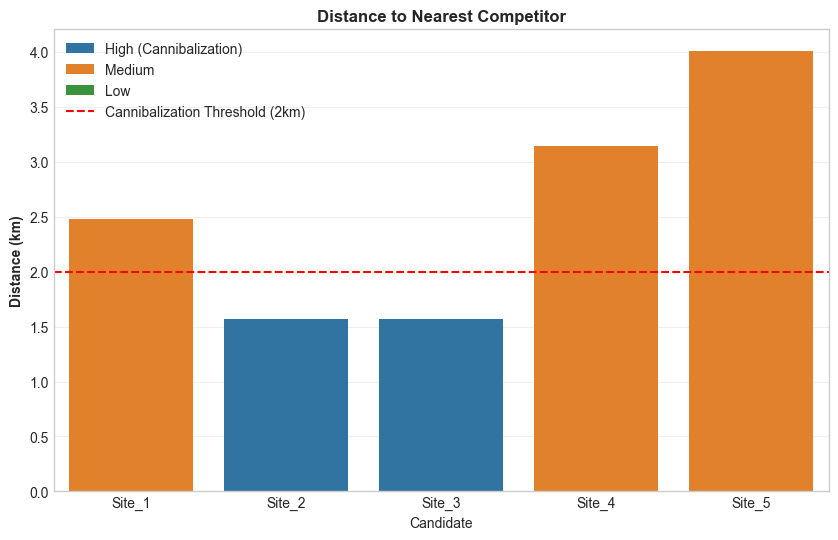

In [10]:
# Competitor Distance Analysis (Cannibalization Risk)
print('\n=== Competitor Distance Analysis ===')

# Calculate distance matrix between all candidates and competitors
dists = cdist(candidates[['lon', 'lat']], competitors[['lon', 'lat']]) * 111

# Find nearest competitor for each candidate
min_dists = dists.min(axis=1)
nearest_idx = dists.argmin(axis=1)
nearest_names = competitors.iloc[nearest_idx]['name'].values

comp_analysis = pd.DataFrame({
    'Candidate': candidates['site_id'],
    'Nearest_Competitor': nearest_names,
    'Distance_km': min_dists
})

# Flag high risk (< 2km)
comp_analysis['Risk_Level'] = pd.cut(comp_analysis['Distance_km'], 
                                     bins=[0, 2, 5, 100], 
                                     labels=['High (Cannibalization)', 'Medium', 'Low'])

print(comp_analysis)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=comp_analysis, x='Candidate', y='Distance_km', hue='Risk_Level', dodge=False)
plt.axhline(2, color='red', linestyle='--', label='Cannibalization Threshold (2km)')
plt.title('Distance to Nearest Competitor', fontweight='bold')
plt.ylabel('Distance (km)', fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

top_site = scores_df.iloc[0]
second_site = scores_df.iloc[1]
third_site = scores_df.iloc[2]

summary_md = f"""
## 🎯 Key Findings & Recommendations

### Top Site Recommendation: {top_site['site_id']}
- **Total Score**: {top_site['total_score']:.3f}
- **Population (1km)**: {top_site['population_1km']:,.0f}
- **Competitor Distance**: {top_site['min_competitor_dist_km']:.2f} km

### Decision Matrix
Recommended priority order for expansion:
1. **{top_site['site_id']}**: Optimal balance of demand, income, and competition.
2. **{second_site['site_id']}**: Strong alternative, slightly lower accessibility.
3. **{third_site['site_id']}**: Niche opportunity in underserved area.

### Strategic Insights
1. **Market Saturation**: {len(comp_analysis[comp_analysis['Risk_Level']=='High (Cannibalization)'])} sites have high cannibalization risk.
2. **Huff Model**: Larger stores capture wider market areas (distance decay = 2.0).
3. **Income Correlation**: Nighttime lights show purchasing power distribution.

### Implementation Roadmap
1. Site survey and lease negotiation for {top_site['site_id']}.
2. Traffic counts to validate population estimates.
3. Competitive analysis (pricing, product mix).
"""
display(Markdown(summary_md))


## 🎯 Key Findings & Recommendations

### Top Site Recommendation: Site_1
- **Total Score**: 0.809
- **Population (1km)**: 44,984
- **Competitor Distance**: 2.48 km

### Decision Matrix
Recommended priority order for expansion:
1. **Site_1**: Optimal balance of demand, income, and competition.
2. **Site_3**: Strong alternative, slightly lower accessibility.
3. **Site_4**: Niche opportunity in underserved area.

### Strategic Insights
1. **Market Saturation**: 2 sites have high cannibalization risk.
2. **Huff Model**: Larger stores capture wider market areas (distance decay = 2.0).
3. **Income Correlation**: Nighttime lights show purchasing power distribution.

### Implementation Roadmap
1. Site survey and lease negotiation for Site_1.
2. Traffic counts to validate population estimates.
3. Competitive analysis (pricing, product mix).
